# CareerPath AI - Notebook Proses Data Science

Notebook ini menyajikan alur lengkap Data Science untuk proyek **CareerPath AI** menggunakan data lowongan kerja dan skill. Fokus utama notebook adalah membersihkan data, mengintegrasikan skill, menggali insight pasar kerja, dan menyiapkan feature engineering yang siap dipakai pada tahap AI atau rekomendasi karier.

**Output utama notebook**
- `job_clean_final.csv`
- `job_featured.csv`
- `data_dictionary.csv`
- insight skill dan job market yang siap dipresentasikan

## 1. Import Library

Library yang digunakan pada notebook ini:
- `pandas` untuk manipulasi data
- `numpy` untuk operasi numerik
- `re` untuk pembersihan teks dengan regular expression
- `matplotlib.pyplot` untuk visualisasi dasar
- `seaborn` untuk visualisasi statistik yang lebih rapi

In [1]:
# Import library utama untuk proses analisis data
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

# Pengaturan tampilan agar output tabel dan grafik lebih nyaman dibaca
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (12, 6)

## 2. Data Gathering

Dataset pada proyek ini berasal dari proses scraping platform lowongan kerja seperti **LinkedIn** dan **Glints**. Karena berasal dari scraping, data masih bersifat mentah dan berpotensi memiliki beberapa masalah umum seperti:
- nilai kosong pada kolom tertentu
- format teks yang belum konsisten
- kolom yang kurang relevan untuk analisis
- perbedaan kelengkapan informasi antar lowongan

Pada tahap ini, kita memuat tiga dataset utama:
1. `job_postings.csv` sebagai data lowongan kerja utama
2. `job_skills.csv` sebagai relasi antara lowongan dan kode skill
3. `skills.csv` sebagai kamus skill dari kode ke nama skill

In [2]:
# Membaca seluruh dataset utama proyek
job_raw = pd.read_csv("job_postings.csv")
job_skills = pd.read_csv("job_skills.csv")
skills = pd.read_csv("skills.csv")

print("Ukuran data job_postings:", job_raw.shape)
print("Ukuran data job_skills:", job_skills.shape)
print("Ukuran data skills:", skills.shape)

print("\nContoh data job_postings:")
display(job_raw.head())

print("\nContoh data job_skills:")
display(job_skills.head())

print("\nContoh data skills:")
display(skills.head())

Ukuran data job_postings: (4085, 28)
Ukuran data job_skills: (6858, 2)
Ukuran data skills: (35, 2)

Contoh data job_postings:


,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,applies,original_listed_time,remote_allowed,views,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,scraped
0,2371637339,3199778.0,Sales Executive,"Are you a smart, authentic, pro-active B2B Sales professional?Are you a great listener and a problem solver who is c...",NaN,NaN,NaN,NaN,Full-time,"Central Jakarta, Jakarta, Indonesia",NaN,1.776399e+12,NaN,NaN,https://www.linkedin.com/jobs/view/2371637339/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.791952e+12,NaN,NaN,NaN,1.776400e+12,NaN,0,FULL_TIME,NaN,NaN,1776402696
1,3486411410,14512264.0,Partnership Associate,"Responsibilities :Building strong strategic relationship with existing partnersGet the insights, synthesis and creat...",NaN,NaN,NaN,NaN,Full-time,"South Jakarta, Jakarta, Indonesia",NaN,1.776671e+12,NaN,NaN,https://www.linkedin.com/jobs/view/3486411410/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.779263e+12,NaN,NaN,NaN,1.776671e+12,NaN,0,FULL_TIME,NaN,NaN,1776671355
2,3506214686,NaN,Human Resources Coordinator,🚛 We’re Hiring: Fleet Supervisor!\nPT Surya Mitra Tirta Kencana membuka peluang bagi profesional berpengalaman di bi...,NaN,NaN,NaN,NaN,Full-time,"Surabaya, East Java, Indonesia",NaN,1.776652e+12,NaN,NaN,https://www.linkedin.com/jobs/view/3506214686/?trk=jobs_biz_prem_srch,NaN,SimpleOnsiteApply,1.779244e+12,NaN,NaN,NaN,1.776652e+12,NaN,0,FULL_TIME,NaN,NaN,1776651838
3,3611210067,6451760.0,Finance Accounting Specialist,"Job Description\n\nEngage in the monthly financial close process, including ensuring all costs incurred are properly...",NaN,NaN,NaN,NaN,Full-time,"Jakarta, Indonesia",NaN,1.682244e+12,NaN,NaN,https://www.linkedin.com/jobs/view/3611210067/?trk=jobs_biz_prem_srch,https://careers.shopee.sg/job-detail/J00160745/1?channel=10001,OffsiteApply,1.795200e+12,NaN,Mid-Senior level,NaN,1.776691e+12,careers.shopee.sg,0,FULL_TIME,NaN,NaN,1776690902
4,3645884531,109026465.0,Sales Marketing for Marine & Offshore,"Kualifikasi:Pendidikan minimal D3/S1 di bidang Pemasaran, Teknik Perkapalan, atau Manajemen.Pengalaman minimal 2 tah...",NaN,NaN,NaN,NaN,Full-time,Jakarta Metropolitan Area,NaN,1.776746e+12,NaN,NaN,https://www.linkedin.com/jobs/view/3645884531/?trk=jobs_biz_prem_srch,NaN,ComplexOnsiteApply,1.779338e+12,NaN,NaN,NaN,1.776746e+12,NaN,0,FULL_TIME,NaN,NaN,1776746358



Contoh data job_skills:


,job_id,skill_abr
0,4401464202,DSGN
1,4401464202,ART
2,4401464202,IT
3,4398796723,SALE
4,4398796723,BD



Contoh data skills:


,skill_abr,skill_name
0,DIST,Distribution
1,HCPR,Health Care Provider
2,GENB,General Business
3,PRCH,Purchasing
4,LGL,Legal


## 3. Data Understanding (Assessing)

Tahap understanding bertujuan untuk memahami struktur data sebelum dilakukan cleaning. Kita akan memeriksa:
- informasi umum dataset
- tipe data setiap kolom
- jumlah missing values
- duplikasi data

Hasil dari tahap ini penting karena akan menentukan strategi pembersihan data yang paling tepat.

In [3]:
# Melihat ringkasan struktur dataset utama
print("Informasi dataset job_postings")
job_raw.info()

Informasi dataset job_postings
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4085 entries, 0 to 4084
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   job_id                      4085 non-null   int64  
 1   company_id                  4028 non-null   float64
 2   title                       4085 non-null   object 
 3   description                 4075 non-null   object 
 4   max_salary                  96 non-null     float64
 5   med_salary                  0 non-null      float64
 6   min_salary                  96 non-null     float64
 7   pay_period                  96 non-null     object 
 8   formatted_work_type         4085 non-null   object 
 9   location                    4085 non-null   object 
 10  applies                     0 non-null      float64
 11  original_listed_time        4085 non-null   float64
 12  remote_allowed              607 non-null    float64
 13  vi

In [4]:
# Menghitung missing values dan tipe data agar masalah kualitas data terlihat lebih jelas
missing_summary = (
    job_raw.isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "kolom", 0: "jumlah_missing"})
)
missing_summary["persentase_missing"] = (
    missing_summary["jumlah_missing"] / len(job_raw) * 100
).round(2)
missing_summary = missing_summary.sort_values(
    by="jumlah_missing", ascending=False
)

dtype_summary = (
    job_raw.dtypes.astype(str)
    .reset_index()
    .rename(columns={"index": "kolom", 0: "tipe_data"})
)

duplicate_rows = job_raw.duplicated().sum()
duplicate_job_id = job_raw.duplicated(subset=["job_id"]).sum()

print("Jumlah duplicate row :", duplicate_rows)
print("Jumlah duplicate job_id :", duplicate_job_id)
print("\nRingkasan missing values:")
display(missing_summary.head(15))
print("\nRingkasan tipe data:")
display(dtype_summary)

Jumlah duplicate row : 0
Jumlah duplicate job_id : 0

Ringkasan missing values:


,kolom,jumlah_missing,persentase_missing
10,applies,4085,100.00
5,med_salary,4085,100.00
18,closed_time,4085,100.00
13,views,4085,100.00
20,skills_desc,4011,98.19
7,pay_period,3989,97.65
4,max_salary,3989,97.65
26,compensation_type,3989,97.65
25,currency,3989,97.65
6,min_salary,3989,97.65



Ringkasan tipe data:


,kolom,tipe_data
0,job_id,int64
1,company_id,float64
2,title,object
3,description,object
4,max_salary,float64
5,med_salary,float64
6,min_salary,float64
7,pay_period,object
8,formatted_work_type,object
9,location,object


### Masalah Data yang Ditemukan

Berdasarkan pemeriksaan awal, beberapa masalah yang umum muncul pada data lowongan kerja mentah adalah:
- banyak kolom memiliki missing value sangat tinggi, terutama kolom salary, `applies`, `views`, dan informasi tambahan lainnya
- deskripsi pekerjaan masih berupa teks panjang dengan line break, spasi ganda, dan karakter yang belum rapi
- ada kolom yang relevan untuk presentasi insight, tetapi tidak semuanya cocok untuk feature engineering secara langsung
- informasi experience level tidak selalu tersedia sehingga perlu diturunkan dari judul pekerjaan

Karena itu, tahap cleaning perlu dibuat hati-hati: kolom penting dipertahankan, missing value ditangani secara strategis, dan teks dibersihkan agar siap dipakai untuk analisis lanjutan.

## 4. Data Cleaning

Langkah cleaning yang dilakukan:
1. standarisasi nama kolom
2. menghapus duplikasi
3. menangani missing values pada kolom yang penting
4. membersihkan teks deskripsi pekerjaan
5. membuat estimasi salary sederhana bila data salary tersedia

Catatan penting:
- tidak semua nilai kosong harus dipaksa terisi
- untuk kolom numerik yang memang jarang tersedia, nilai kosong bisa dibiarkan agar tidak menimbulkan bias
- untuk kolom kategorikal penting, kita gunakan label seperti `Tidak diketahui`

In [5]:
# Membuat salinan data agar dataset mentah tetap aman
job_clean = job_raw.copy()

# Standarisasi nama kolom agar konsisten
job_clean.columns = (
    job_clean.columns.str.strip().str.lower().str.replace(" ", "_", regex=False)
)

# Menghapus duplikasi baris penuh dan duplikasi job_id
job_clean = job_clean.drop_duplicates()
job_clean = job_clean.drop_duplicates(subset=["job_id"]).reset_index(drop=True)

# Membersihkan spasi di seluruh kolom bertipe object
object_cols = job_clean.select_dtypes(include="object").columns
for col in object_cols:
    job_clean[col] = job_clean[col].astype("string").str.strip()

# Menangani missing value pada kolom penting
fill_text = {
    "title": "Tidak diketahui",
    "location": "Tidak diketahui",
    "formatted_work_type": "Tidak diketahui",
    "application_type": "Tidak diketahui",
    "formatted_experience_level": "Tidak diketahui",
    "posting_domain": "Tidak diketahui",
    "work_type": "Tidak diketahui",
    "currency": "Tidak diketahui",
    "compensation_type": "Tidak diketahui",
    "pay_period": "Tidak diketahui",
}

for col, value in fill_text.items():
    if col in job_clean.columns:
        job_clean[col] = job_clean[col].fillna(value)

# Kolom boolean yang kosong dianggap belum ada informasi
if "remote_allowed" in job_clean.columns:
    job_clean["remote_allowed"] = job_clean["remote_allowed"].fillna(False).astype(bool)

# Kolom numerik diubah ke bentuk numerik agar aman untuk analisis lanjutan
numeric_cols = [
    "company_id",
    "max_salary",
    "med_salary",
    "min_salary",
    "applies",
    "original_listed_time",
    "views",
    "expiry",
    "closed_time",
    "listed_time",
    "sponsored",
    "scraped",
]
for col in numeric_cols:
    if col in job_clean.columns:
        job_clean[col] = pd.to_numeric(job_clean[col], errors="coerce")

# Mengisi description yang kosong dengan string kosong agar proses cleaning teks lebih stabil
job_clean["description"] = job_clean["description"].fillna("")

def clean_description(text):
    # Membersihkan karakter khusus, line break, dan spasi ganda dari deskripsi
    text = str(text)
    replacements = {
        "â€™": "'",
        "â€œ": '"',
        "â€": '"',
        "â€“": "-",
        "â€¦": "...",
        "\xa0": " ",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)

    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"[\r\n\t]+", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

# Menyimpan versi deskripsi sebelum dan sesudah cleaning untuk eksperimen sederhana
job_clean["description_before_clean"] = job_raw["description"].fillna("").astype(str)
job_clean["description"] = job_clean["description"].apply(clean_description)

# Membuat estimasi salary sederhana bila data salary tersedia
job_clean["salary_estimate"] = np.where(
    job_clean["med_salary"].notna(),
    job_clean["med_salary"],
    np.where(
        job_clean["max_salary"].notna() & job_clean["min_salary"].notna(),
        (job_clean["max_salary"] + job_clean["min_salary"]) / 2,
        np.nan,
    ),
)

print("Ukuran data setelah cleaning:", job_clean.shape)
display(job_clean.head())

Ukuran data setelah cleaning: (4085, 30)


,job_id,company_id,title,description,max_salary,med_salary,min_salary,pay_period,formatted_work_type,location,applies,original_listed_time,remote_allowed,views,job_posting_url,application_url,application_type,expiry,closed_time,formatted_experience_level,skills_desc,listed_time,posting_domain,sponsored,work_type,currency,compensation_type,scraped,description_before_clean,salary_estimate
0,2371637339,3199778.0,Sales Executive,"Are you a smart, authentic, pro-active B2B Sales professional?Are you a great listener and a problem solver who is c...",NaN,NaN,NaN,Tidak diketahui,Full-time,"Central Jakarta, Jakarta, Indonesia",NaN,1.776399e+12,False,NaN,https://www.linkedin.com/jobs/view/2371637339/?trk=jobs_biz_prem_srch,<NA>,ComplexOnsiteApply,1.791952e+12,NaN,Tidak diketahui,<NA>,1.776400e+12,Tidak diketahui,0,FULL_TIME,Tidak diketahui,Tidak diketahui,1776402696,"Are you a smart, authentic, pro-active B2B Sales professional?Are you a great listener and a problem solver who is c...",NaN
1,3486411410,14512264.0,Partnership Associate,"Responsibilities :Building strong strategic relationship with existing partnersGet the insights, synthesis and creat...",NaN,NaN,NaN,Tidak diketahui,Full-time,"South Jakarta, Jakarta, Indonesia",NaN,1.776671e+12,False,NaN,https://www.linkedin.com/jobs/view/3486411410/?trk=jobs_biz_prem_srch,<NA>,ComplexOnsiteApply,1.779263e+12,NaN,Tidak diketahui,<NA>,1.776671e+12,Tidak diketahui,0,FULL_TIME,Tidak diketahui,Tidak diketahui,1776671355,"Responsibilities :Building strong strategic relationship with existing partnersGet the insights, synthesis and creat...",NaN
2,3506214686,NaN,Human Resources Coordinator,🚛 We’re Hiring: Fleet Supervisor! PT Surya Mitra Tirta Kencana membuka peluang bagi profesional berpengalaman di bid...,NaN,NaN,NaN,Tidak diketahui,Full-time,"Surabaya, East Java, Indonesia",NaN,1.776652e+12,False,NaN,https://www.linkedin.com/jobs/view/3506214686/?trk=jobs_biz_prem_srch,<NA>,SimpleOnsiteApply,1.779244e+12,NaN,Tidak diketahui,<NA>,1.776652e+12,Tidak diketahui,0,FULL_TIME,Tidak diketahui,Tidak diketahui,1776651838,🚛 We’re Hiring: Fleet Supervisor!\nPT Surya Mitra Tirta Kencana membuka peluang bagi profesional berpengalaman di bi...,NaN
3,3611210067,6451760.0,Finance Accounting Specialist,"Job Description Engage in the monthly financial close process, including ensuring all costs incurred are properly re...",NaN,NaN,NaN,Tidak diketahui,Full-time,"Jakarta, Indonesia",NaN,1.682244e+12,False,NaN,https://www.linkedin.com/jobs/view/3611210067/?trk=jobs_biz_prem_srch,https://careers.shopee.sg/job-detail/J00160745/1?channel=10001,OffsiteApply,1.795200e+12,NaN,Mid-Senior level,<NA>,1.776691e+12,careers.shopee.sg,0,FULL_TIME,Tidak diketahui,Tidak diketahui,1776690902,"Job Description\n\nEngage in the monthly financial close process, including ensuring all costs incurred are properly...",NaN
4,3645884531,109026465.0,Sales Marketing for Marine & Offshore,"Kualifikasi:Pendidikan minimal D3/S1 di bidang Pemasaran, Teknik Perkapalan, atau Manajemen.Pengalaman minimal 2 tah...",NaN,NaN,NaN,Tidak diketahui,Full-time,Jakarta Metropolitan Area,NaN,1.776746e+12,False,NaN,https://www.linkedin.com/jobs/view/3645884531/?trk=jobs_biz_prem_srch,<NA>,ComplexOnsiteApply,1.779338e+12,NaN,Tidak diketahui,<NA>,1.776746e+12,Tidak diketahui,0,FULL_TIME,Tidak diketahui,Tidak diketahui,1776746358,"Kualifikasi:Pendidikan minimal D3/S1 di bidang Pemasaran, Teknik Perkapalan, atau Manajemen.Pengalaman minimal 2 tah...",NaN


### Penjelasan Cleaning

Beberapa keputusan cleaning pada notebook ini dibuat dengan pertimbangan analitis:
- `title`, `location`, dan beberapa kolom kategorikal penting diisi dengan `Tidak diketahui` agar tetap dapat dikelompokkan saat analisis
- kolom deskripsi dibersihkan karena sangat penting untuk NLP, pencarian keyword, dan pembentukan fitur
- kolom salary tidak dipaksa penuh, tetapi dibuat `salary_estimate` bila data memungkinkan
- kolom `description_before_clean` disimpan sementara agar kita bisa membandingkan hasil sebelum dan sesudah cleaning

In [6]:
# Membandingkan kondisi missing values sebelum dan sesudah cleaning
missing_before = job_raw.isna().sum().rename("sebelum")
missing_after = job_clean.drop(columns=["description_before_clean"]).isna().sum().rename("sesudah")

cleaning_comparison = (
    pd.concat([missing_before, missing_after], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={"index": "kolom"})
)
cleaning_comparison["perubahan_missing"] = (
    cleaning_comparison["sebelum"] - cleaning_comparison["sesudah"]
)

print("Perbandingan missing values sebelum vs sesudah cleaning:")
display(cleaning_comparison.sort_values("perubahan_missing", ascending=False).head(15))

print("\nContoh deskripsi sebelum vs sesudah cleaning:")
sample_desc = job_clean.loc[:, ["title", "description_before_clean", "description"]].head(3)
display(sample_desc)

Perbandingan missing values sebelum vs sesudah cleaning:


,kolom,sebelum,sesudah,perubahan_missing
7,pay_period,3989,0,3989
26,compensation_type,3989,0,3989
25,currency,3989,0,3989
12,remote_allowed,3478,0,3478
19,formatted_experience_level,2947,0,2947
22,posting_domain,2487,0,2487
3,description,10,0,10
6,min_salary,3989,3989,0
5,med_salary,4085,4085,0
4,max_salary,3989,3989,0



Contoh deskripsi sebelum vs sesudah cleaning:


,title,description_before_clean,description
0,Sales Executive,"Are you a smart, authentic, pro-active B2B Sales professional?Are you a great listener and a problem solver who is c...","Are you a smart, authentic, pro-active B2B Sales professional?Are you a great listener and a problem solver who is c..."
1,Partnership Associate,"Responsibilities :Building strong strategic relationship with existing partnersGet the insights, synthesis and creat...","Responsibilities :Building strong strategic relationship with existing partnersGet the insights, synthesis and creat..."
2,Human Resources Coordinator,🚛 We’re Hiring: Fleet Supervisor!\nPT Surya Mitra Tirta Kencana membuka peluang bagi profesional berpengalaman di bi...,🚛 We’re Hiring: Fleet Supervisor! PT Surya Mitra Tirta Kencana membuka peluang bagi profesional berpengalaman di bid...


## 5. Data Dictionary

Data dictionary membantu dokumentasi dataset agar mudah dipahami oleh tim data, tim AI, maupun stakeholder non-teknis. Tabel berikut berisi:
- nama kolom
- tipe data
- deskripsi singkat

In [7]:
# Menyusun data dictionary untuk dataset hasil cleaning
column_description = {
    "job_id": "ID unik untuk setiap lowongan pekerjaan",
    "company_id": "ID perusahaan yang memasang lowongan",
    "title": "Judul posisi pekerjaan",
    "description": "Deskripsi pekerjaan yang sudah dibersihkan",
    "max_salary": "Gaji maksimum bila tersedia",
    "med_salary": "Gaji median bila tersedia",
    "min_salary": "Gaji minimum bila tersedia",
    "pay_period": "Periode pembayaran gaji, misalnya bulanan atau tahunan",
    "formatted_work_type": "Bentuk kerja hasil formatting dari sumber data",
    "location": "Lokasi pekerjaan",
    "applies": "Jumlah pelamar bila tersedia",
    "original_listed_time": "Waktu publikasi asli dari sumber data",
    "remote_allowed": "Penanda apakah lowongan mendukung kerja remote",
    "views": "Jumlah view lowongan bila tersedia",
    "job_posting_url": "URL lowongan pekerjaan",
    "application_url": "URL aplikasi atau pendaftaran",
    "application_type": "Tipe proses aplikasi",
    "expiry": "Waktu kedaluwarsa lowongan",
    "closed_time": "Waktu penutupan lowongan bila tersedia",
    "formatted_experience_level": "Level pengalaman dari sumber data",
    "skills_desc": "Deskripsi skill dari sumber data bila tersedia",
    "listed_time": "Timestamp waktu listing",
    "posting_domain": "Domain sumber lowongan",
    "sponsored": "Penanda apakah lowongan bersponsor",
    "work_type": "Tipe kerja dalam format mentah",
    "currency": "Mata uang gaji",
    "compensation_type": "Jenis kompensasi",
    "scraped": "Timestamp saat data discrape",
    "description_before_clean": "Deskripsi pekerjaan sebelum pembersihan teks",
    "salary_estimate": "Estimasi gaji dari median atau rata-rata min dan max salary",
}

data_dictionary = pd.DataFrame({
    "nama_kolom": job_clean.columns,
    "tipe_data": job_clean.dtypes.astype(str).values,
    "deskripsi": [column_description.get(col, "Belum ada deskripsi") for col in job_clean.columns],
})

display(data_dictionary)

# Menyimpan data dictionary sebagai file CSV agar mudah dipakai ulang
data_dictionary.to_csv("data_dictionary.csv", index=False)

,nama_kolom,tipe_data,deskripsi
0,job_id,int64,ID unik untuk setiap lowongan pekerjaan
1,company_id,float64,ID perusahaan yang memasang lowongan
2,title,string,Judul posisi pekerjaan
3,description,object,Deskripsi pekerjaan yang sudah dibersihkan
4,max_salary,float64,Gaji maksimum bila tersedia
5,med_salary,float64,Gaji median bila tersedia
6,min_salary,float64,Gaji minimum bila tersedia
7,pay_period,string,"Periode pembayaran gaji, misalnya bulanan atau tahunan"
8,formatted_work_type,string,Bentuk kerja hasil formatting dari sumber data
9,location,string,Lokasi pekerjaan


## 6. Integrasi Data Skill

Integrasi dilakukan dalam dua tahap:
1. menggabungkan `job_skills` dengan `skills` berdasarkan `skill_abr`
2. menggabungkan hasilnya dengan `job_clean` berdasarkan `job_id`

Tujuan tahap ini adalah menghasilkan dataset yang dapat menunjukkan relasi antara lowongan kerja dan skill yang dibutuhkan, minimal dalam bentuk:
- `job_id`
- `title`
- `skill_name`

In [8]:
# Merge mapping job ke skill code dengan kamus skill
job_skill_map = job_skills.merge(skills, on="skill_abr", how="left")

# Merge hasil skill mapping dengan dataset job yang sudah dibersihkan
job_skill_final = job_clean.merge(
    job_skill_map[["job_id", "skill_abr", "skill_name"]],
    on="job_id",
    how="left",
)

skill_view = job_skill_final[["job_id", "title", "skill_name"]].dropna(subset=["skill_name"])

print("Ukuran hasil integrasi skill:", skill_view.shape)
display(skill_view.head(10))

Ukuran hasil integrasi skill: (6858, 3)


,job_id,title,skill_name
0,2371637339,Sales Executive,Sales
1,2371637339,Sales Executive,Business Development
3,3506214686,Human Resources Coordinator,Human Resources
4,3611210067,Finance Accounting Specialist,Finance
5,3611210067,Finance Accounting Specialist,Accounting/Auditing
7,3776621804,Manajer Sumber Daya Manusia,Human Resources
8,3823440363,Strategic Project Management,Other
9,3918806038,Labs Bootcamp Program,Information Technology
10,3967846204,Business Product Manager (Games) - Sea Labs,Project Management
11,3967846204,Business Product Manager (Games) - Sea Labs,Strategy/Planning


## 7. Analisis Skill

Tahap ini bertujuan menjawab pertanyaan: skill apa yang paling sering diminta oleh pasar kerja pada dataset ini? Analisis dilakukan dengan menghitung frekuensi `skill_name` dari hasil merge.

,skill_name,jumlah
0,Sales,1064
1,Information Technology,844
2,Business Development,655
3,Engineering,486
4,Marketing,401
5,Management,351
6,Other,309
7,Manufacturing,307
8,Finance,304
9,Accounting/Auditing,173


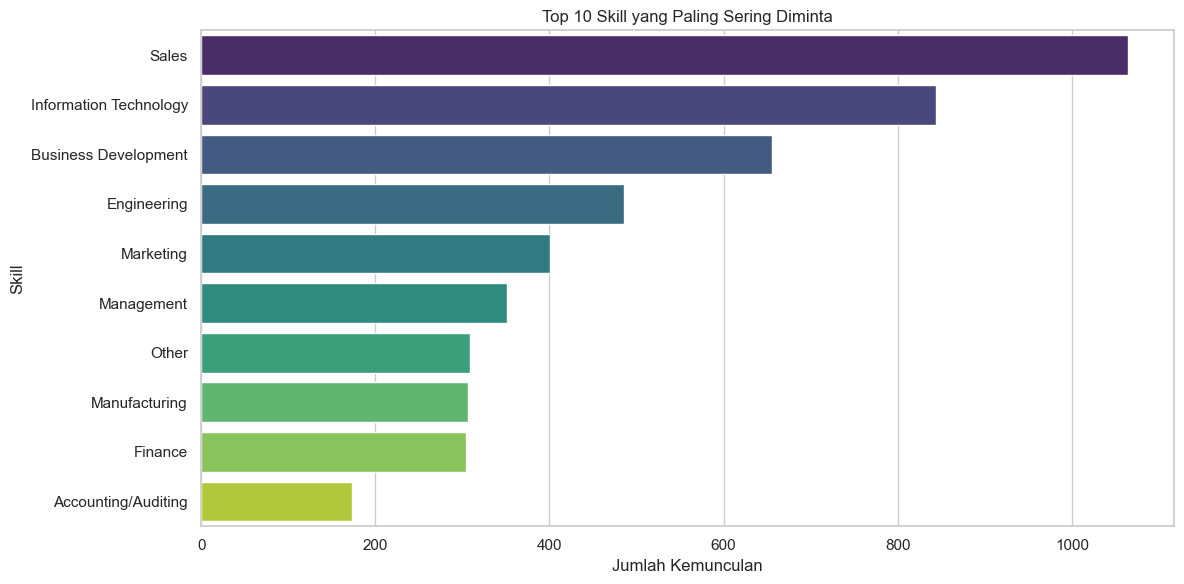

Insight: skill paling sering diminta adalah 'Sales' dengan 1064 kemunculan pada data skill.
Interpretasi: skill dengan frekuensi tinggi layak dijadikan prioritas pada fitur rekomendasi karier, penyusunan learning path, dan pemetaan skill gap kandidat.


In [9]:
# Menghitung skill yang paling sering muncul pada seluruh lowongan
top_skills = (
    skill_view["skill_name"]
    .value_counts()
    .rename_axis("skill_name")
    .reset_index(name="jumlah")
    .head(10)
)

display(top_skills)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_skills,
    x="jumlah",
    y="skill_name",
    hue="skill_name",
    palette="viridis",
    legend=False,
)
plt.title("Top 10 Skill yang Paling Sering Diminta")
plt.xlabel("Jumlah Kemunculan")
plt.ylabel("Skill")
plt.tight_layout()
plt.show()

skill_teratas = top_skills.iloc[0]
print(
    f"Insight: skill paling sering diminta adalah '{skill_teratas['skill_name']}' "
    f"dengan {int(skill_teratas['jumlah'])} kemunculan pada data skill."
)
print(
    "Interpretasi: skill dengan frekuensi tinggi layak dijadikan prioritas pada fitur rekomendasi karier, "
    "penyusunan learning path, dan pemetaan skill gap kandidat."
)

### Insight Analisis Skill

Grafik top skill membantu melihat skill inti yang paling sering diminta oleh pasar. Jika beberapa skill mendominasi data, maka:
- skill tersebut sangat relevan untuk kurikulum pelatihan
- skill tersebut cocok dijadikan kata kunci utama pada model rekomendasi
- CareerPath AI dapat memanfaatkannya untuk menyusun prioritas pembelajaran berdasarkan permintaan pasar

## 8. Analisis Skill per Job

Analisis ini melihat hubungan antara judul pekerjaan dan skill dominan. Kita kelompokkan data berdasarkan `title` dan `skill_name`, lalu ambil skill dengan frekuensi tertinggi untuk setiap judul pekerjaan.

,title,skill_name,jumlah
4277,Sales Executive,Sales,39
4343,Sales Promoter Leader,Sales,24
3837,Project Manager,Project Management,15
4301,Sales Manager,Sales,14
349,Area Sales Promotion Supervisor,Business Development,11
4051,Remote Recruiter (Freelance / Solo / Independent),Human Resources,10
4807,Software Engineer,Engineering,10
345,Area Sales Promotion Representatif,Business Development,10
4363,"Sales Supervisor, SATO, Indonesia",Business Development,10
726,Business Development Manager,Business Development,10


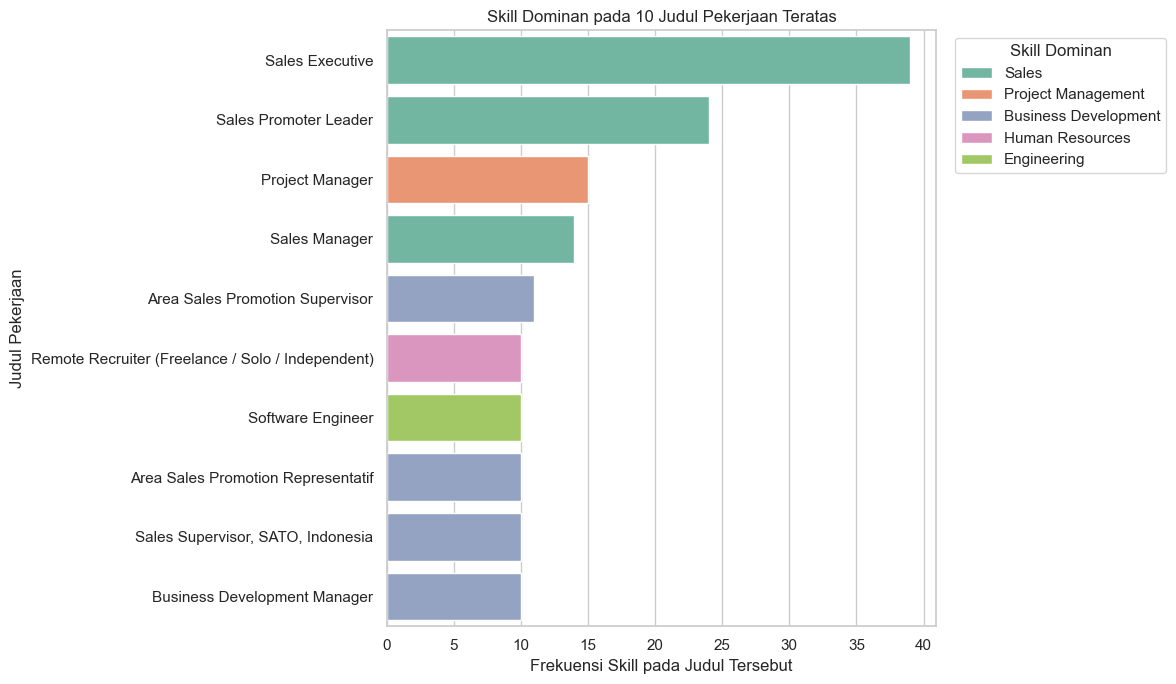

Insight: analisis ini menunjukkan bahwa setiap kelompok jabatan memiliki kombinasi skill yang berbeda. Informasi ini penting untuk rekomendasi karier berbasis role, bukan hanya berbasis skill tunggal.


In [10]:
# Menghitung skill dominan untuk setiap judul pekerjaan
skill_per_title = (
    skill_view.groupby(["title", "skill_name"])
    .size()
    .reset_index(name="jumlah")
)

dominant_skill_per_title = (
    skill_per_title.sort_values(["title", "jumlah", "skill_name"], ascending=[True, False, True])
    .drop_duplicates(subset=["title"])
    .sort_values("jumlah", ascending=False)
)

display(dominant_skill_per_title.head(15))

plt.figure(figsize=(12, 7))
sns.barplot(
    data=dominant_skill_per_title.head(10),
    x="jumlah",
    y="title",
    hue="skill_name",
    dodge=False,
    palette="Set2",
)
plt.title("Skill Dominan pada 10 Judul Pekerjaan Teratas")
plt.xlabel("Frekuensi Skill pada Judul Tersebut")
plt.ylabel("Judul Pekerjaan")
plt.legend(title="Skill Dominan", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print(
    "Insight: analisis ini menunjukkan bahwa setiap kelompok jabatan memiliki kombinasi skill yang berbeda. "
    "Informasi ini penting untuk rekomendasi karier berbasis role, bukan hanya berbasis skill tunggal."
)

### Insight Hubungan Job dan Skill

Hasil analisis skill per job memperlihatkan bahwa hubungan antara role dan skill bersifat spesifik. Artinya:
- judul pekerjaan tidak bisa dianalisis secara terpisah dari skill
- model AI untuk CareerPath AI sebaiknya mempertimbangkan pasangan `role-skill`
- pendekatan ini membantu sistem memberikan rekomendasi yang lebih presisi sesuai target jabatan pengguna

## 9. EDA Tambahan

Selain skill, kita juga perlu memahami pola pasar kerja secara umum. Pada bagian ini kita eksplorasi:
- judul pekerjaan yang paling sering muncul
- lokasi yang paling sering muncul
- distribusi tipe kerja

Setiap grafik dilengkapi penjelasan agar insight yang dihasilkan mudah dipakai untuk presentasi.

,title,jumlah
0,Sales Executive,40
1,Sales Promoter Leader,24
2,Sales Manager,16
3,Project Manager,15
4,Software Engineer,12
5,Area Sales Promotion Supervisor,11
6,Business Development Manager,11
7,Remote Recruiter (Freelance / Solo / Independent),10
8,Area Sales Promotion Representatif,10
9,CPC Cashier,10


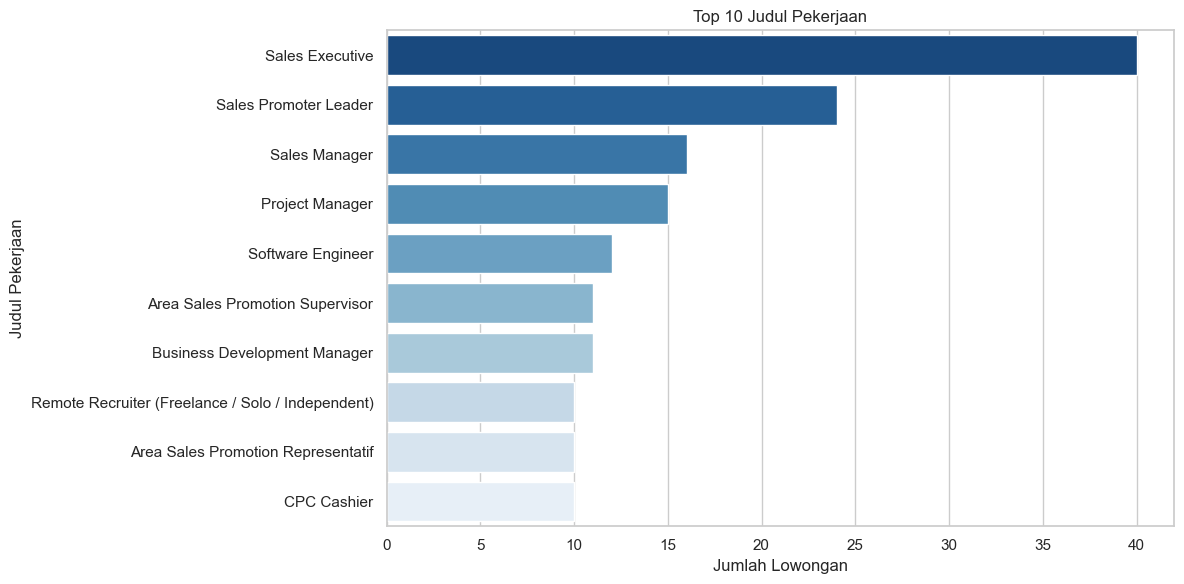

Insight: judul pekerjaan yang paling sering muncul menunjukkan role dengan demand tinggi. Role seperti ini cocok dijadikan fokus awal pada dashboard insight dan modul rekomendasi karier.


In [11]:
# Top job title untuk melihat role yang paling banyak dicari
top_titles = (
    job_clean["title"]
    .value_counts()
    .head(10)
    .rename_axis("title")
    .reset_index(name="jumlah")
)

display(top_titles)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_titles,
    x="jumlah",
    y="title",
    hue="title",
    palette="Blues_r",
    legend=False,
)
plt.title("Top 10 Judul Pekerjaan")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Judul Pekerjaan")
plt.tight_layout()
plt.show()

print(
    "Insight: judul pekerjaan yang paling sering muncul menunjukkan role dengan demand tinggi. "
    "Role seperti ini cocok dijadikan fokus awal pada dashboard insight dan modul rekomendasi karier."
)

,location,jumlah
0,"Jakarta, Indonesia",867
1,Jakarta Metropolitan Area,458
2,"Jakarta, Jakarta, Indonesia",355
3,Indonesia,234
4,APAC,207
5,"Tangerang, Banten, Indonesia",136
6,"South Jakarta, Jakarta, Indonesia",81
7,"Surabaya, East Java, Indonesia",79
8,"Bandung, West Java, Indonesia",77
9,"Batam, Riau Islands, Indonesia",76


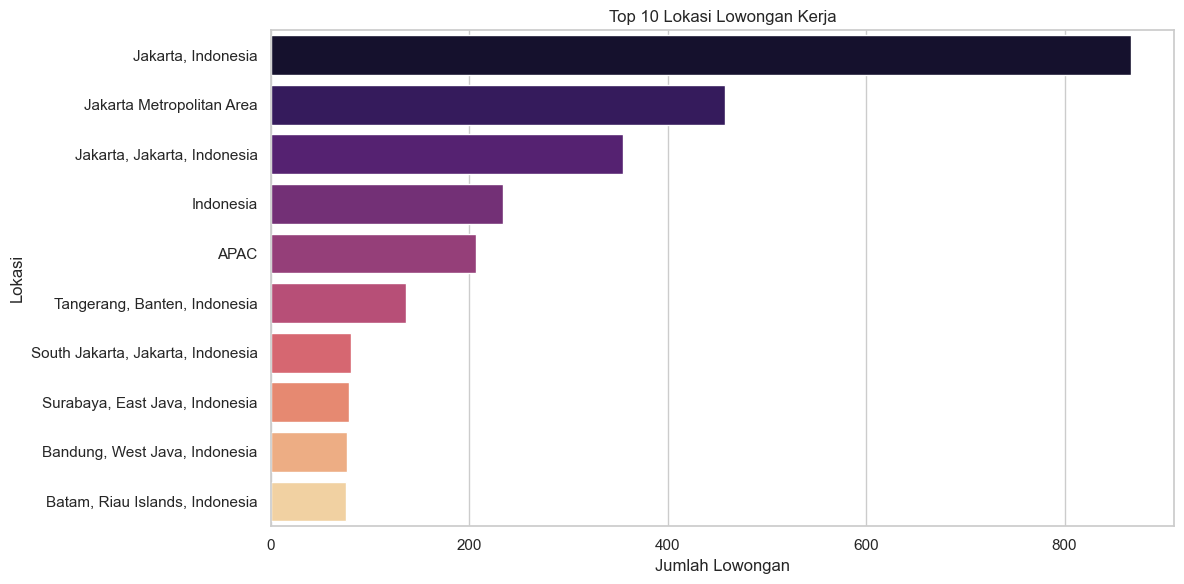

Insight: lokasi dengan jumlah lowongan tertinggi menunjukkan pusat aktivitas perekrutan. Informasi ini berguna untuk segmentasi wilayah dan strategi personalisasi berdasarkan lokasi.


In [12]:
# Top location untuk memetakan konsentrasi pasar kerja
top_locations = (
    job_clean["location"]
    .value_counts()
    .head(10)
    .rename_axis("location")
    .reset_index(name="jumlah")
)

display(top_locations)

plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_locations,
    x="jumlah",
    y="location",
    hue="location",
    palette="magma",
    legend=False,
)
plt.title("Top 10 Lokasi Lowongan Kerja")
plt.xlabel("Jumlah Lowongan")
plt.ylabel("Lokasi")
plt.tight_layout()
plt.show()

print(
    "Insight: lokasi dengan jumlah lowongan tertinggi menunjukkan pusat aktivitas perekrutan. "
    "Informasi ini berguna untuk segmentasi wilayah dan strategi personalisasi berdasarkan lokasi."
)

,formatted_work_type,jumlah
0,Full-time,3157
1,Contract,652
2,Internship,134
3,Part-time,96
4,Temporary,20
5,Other,20
6,Volunteer,6


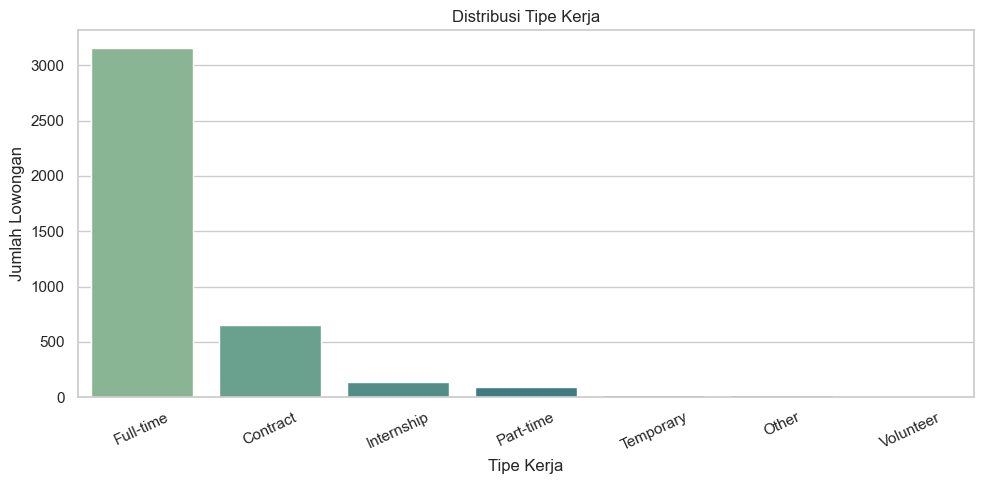

Insight: distribusi tipe kerja membantu melihat apakah pasar didominasi full-time, contract, hybrid, atau bentuk kerja lainnya. Insight ini bisa dipakai untuk filtering preferensi pengguna pada aplikasi CareerPath AI.


In [13]:
# Distribusi tipe kerja untuk memahami pola pekerjaan yang ditawarkan
work_type_dist = (
    job_clean["formatted_work_type"]
    .fillna("Tidak diketahui")
    .value_counts()
    .head(10)
    .rename_axis("formatted_work_type")
    .reset_index(name="jumlah")
)

display(work_type_dist)

plt.figure(figsize=(10, 5))
sns.barplot(
    data=work_type_dist,
    x="formatted_work_type",
    y="jumlah",
    hue="formatted_work_type",
    palette="crest",
    legend=False,
)
plt.title("Distribusi Tipe Kerja")
plt.xlabel("Tipe Kerja")
plt.ylabel("Jumlah Lowongan")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

print(
    "Insight: distribusi tipe kerja membantu melihat apakah pasar didominasi full-time, contract, hybrid, atau bentuk kerja lainnya. "
    "Insight ini bisa dipakai untuk filtering preferensi pengguna pada aplikasi CareerPath AI."
)

## 10. Feature Engineering

Tahap feature engineering bertujuan membentuk fitur yang lebih informatif untuk kebutuhan AI Engineer. Fitur yang dibuat:
- `total_skill`: jumlah skill pada setiap lowongan
- `dominant_skill`: skill paling dominan pada setiap lowongan
- `experience_level_ai`: level pengalaman yang diturunkan dari judul pekerjaan
- `description_length`: panjang deskripsi sebagai indikator kompleksitas informasi

Fitur-fitur ini nantinya dapat dipakai untuk:
- model rekomendasi lowongan
- sistem pencocokan CV dengan pekerjaan
- segmentasi lowongan berdasarkan tingkat pengalaman

In [14]:
# Menghitung frekuensi global skill sebagai dasar penentuan dominant skill per lowongan
global_skill_freq = skill_view["skill_name"].value_counts()

skill_rank_per_job = (
    skill_view.assign(skill_rank=skill_view["skill_name"].map(global_skill_freq))
    .sort_values(["job_id", "skill_rank", "skill_name"], ascending=[True, False, True])
    .drop_duplicates(subset=["job_id"])
    .rename(columns={"skill_name": "dominant_skill"})
    [["job_id", "dominant_skill"]]
)

total_skill_per_job = (
    skill_view.groupby("job_id")["skill_name"]
    .nunique()
    .reset_index(name="total_skill")
)

def classify_experience(title):
    # Menurunkan level pengalaman langsung dari judul pekerjaan
    title = str(title).lower()
    if re.search(r"intern|internship|magang", title):
        return "intern"
    if re.search(r"junior|jr\.?|entry|fresh graduate", title):
        return "junior"
    if re.search(r"senior|sr\.?|lead|principal|head", title):
        return "senior"
    return "mid"

job_featured = job_clean.merge(total_skill_per_job, on="job_id", how="left")
job_featured = job_featured.merge(skill_rank_per_job, on="job_id", how="left")

job_featured["total_skill"] = job_featured["total_skill"].fillna(0).astype(int)
job_featured["dominant_skill"] = job_featured["dominant_skill"].fillna("Tidak diketahui")
job_featured["experience_level_ai"] = job_featured["title"].apply(classify_experience)
job_featured["description_length"] = (
    job_featured["description"].fillna("").str.split().str.len()
)

feature_preview = job_featured[
    [
        "job_id",
        "title",
        "location",
        "total_skill",
        "dominant_skill",
        "experience_level_ai",
        "description_length",
        "salary_estimate",
    ]
].head(10)

display(feature_preview)

,job_id,title,location,total_skill,dominant_skill,experience_level_ai,description_length,salary_estimate
0,2371637339,Sales Executive,"Central Jakarta, Jakarta, Indonesia",2,Sales,mid,359,NaN
1,3486411410,Partnership Associate,"South Jakarta, Jakarta, Indonesia",0,Tidak diketahui,mid,97,NaN
2,3506214686,Human Resources Coordinator,"Surabaya, East Java, Indonesia",1,Human Resources,mid,62,NaN
3,3611210067,Finance Accounting Specialist,"Jakarta, Indonesia",2,Finance,mid,278,NaN
4,3645884531,Sales Marketing for Marine & Offshore,Jakarta Metropolitan Area,0,Tidak diketahui,mid,154,NaN
5,3776621804,Manajer Sumber Daya Manusia,"Kuta, Bali, Indonesia",1,Human Resources,mid,136,NaN
6,3823440363,Strategic Project Management,"Jakarta, Indonesia",1,Other,mid,92,NaN
7,3918806038,Labs Bootcamp Program,"Jakarta, Indonesia",1,Information Technology,mid,284,NaN
8,3967846204,Business Product Manager (Games) - Sea Labs,"Jakarta, Indonesia",3,Project Management,mid,388,NaN
9,4027736130,"Demand Planning - Business Intelligence & Planning, ShopeeFood","Jakarta, Indonesia",3,Analyst,mid,214,NaN


### Nilai Tambah Feature Engineering

Feature engineering di atas memberikan manfaat praktis:
- `total_skill` dapat menjadi indikator kompleksitas requirement
- `dominant_skill` membantu pengelompokan lowongan berdasarkan fokus kompetensi
- `experience_level_ai` sangat berguna ketika data level pengalaman dari sumber tidak lengkap
- `description_length` dapat dipakai sebagai proxy sederhana untuk kepadatan informasi lowongan

## 11. Eksperimen Sederhana

Sebagai validasi awal, kita bandingkan kondisi data sebelum dan sesudah cleaning. Eksperimen sederhana ini membantu menunjukkan bahwa cleaning bukan sekadar kosmetik, tetapi benar-benar meningkatkan kesiapan data untuk analisis dan AI.

In [15]:
# Membandingkan statistik deskripsi sebelum dan sesudah cleaning
experiment_df = pd.DataFrame({
    "metrik": [
        "Rata-rata jumlah kata sebelum cleaning",
        "Rata-rata jumlah kata sesudah cleaning",
        "Jumlah deskripsi kosong sebelum cleaning",
        "Jumlah deskripsi kosong sesudah cleaning",
    ],
    "nilai": [
        job_clean["description_before_clean"].str.split().str.len().fillna(0).mean().round(2),
        job_clean["description"].str.split().str.len().fillna(0).mean().round(2),
        (job_clean["description_before_clean"].str.strip() == "").sum(),
        (job_clean["description"].str.strip() == "").sum(),
    ],
})

display(experiment_df)

print(
    "Insight: setelah cleaning, struktur teks menjadi lebih konsisten sehingga lebih siap untuk analisis keyword, NLP, "
    "dan perhitungan fitur berbasis deskripsi pekerjaan."
)

,metrik,nilai
0,Rata-rata jumlah kata sebelum cleaning,285.81
1,Rata-rata jumlah kata sesudah cleaning,285.61
2,Jumlah deskripsi kosong sebelum cleaning,10.00
3,Jumlah deskripsi kosong sesudah cleaning,12.00


Insight: setelah cleaning, struktur teks menjadi lebih konsisten sehingga lebih siap untuk analisis keyword, NLP, dan perhitungan fitur berbasis deskripsi pekerjaan.


## 12. Final Output

Pada tahap akhir, kita simpan dua dataset utama:
- `job_clean_final.csv` sebagai dataset bersih utama
- `job_featured.csv` sebagai dataset yang sudah ditambah fitur turunan

Selain itu, `data_dictionary.csv` juga sudah disimpan pada tahap dokumentasi agar bisa dipakai ulang oleh tim.

In [16]:
# Menyimpan dataset akhir untuk kebutuhan analisis dan AI
job_clean_final = job_clean.drop(columns=["description_before_clean"]).copy()

job_clean_final.to_csv("job_clean_final.csv", index=False)
job_featured.to_csv("job_featured.csv", index=False)

print("File berhasil disimpan:")
print("- job_clean_final.csv")
print("- job_featured.csv")
print("- data_dictionary.csv")

File berhasil disimpan:
- job_clean_final.csv
- job_featured.csv
- data_dictionary.csv


## 13. Kesimpulan

Berdasarkan proses Data Science yang telah dilakukan, beberapa poin utama yang dapat disimpulkan adalah:
- dataset lowongan kerja mentah perlu dibersihkan sebelum dipakai untuk analisis atau AI
- integrasi data skill sangat penting untuk memahami kebutuhan kompetensi pasar
- analisis top skill dan skill per job membantu melihat hubungan antara role dan kompetensi
- insight job market seperti top title, top location, dan tipe kerja dapat digunakan untuk dashboard serta presentasi bisnis
- feature engineering seperti `total_skill`, `dominant_skill`, `experience_level_ai`, dan `description_length` sangat berguna untuk model AI Engineer

Dalam konteks CareerPath AI, hasil notebook ini bisa menjadi fondasi untuk:
- sistem rekomendasi pekerjaan
- pemetaan skill gap pengguna
- penyusunan learning path yang sesuai kebutuhan pasar
- pencocokan antara CV kandidat dan lowongan kerja